This Analysis is primarly focused in providing insights in Newborn 

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
#loading of the data set
newborn_health=pd.read_csv("D:/Newborn Analysis Files/newborn_health_monitoring_with_risk.csv")
newborn_health.head()


,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_gain,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
0,B001,Sara,Female,40.2,3.3,50.0,31.9,12/10/2024,1,-0.02,...,98,Formula,11,9,0,4.2,7.0,Yes,Yes,At Risk
1,B001,Sara,Female,40.2,3.3,50.0,31.9,12/11/2024,2,0.05,...,99,Formula,11,5,2,10.6,NaN,No,No,At Risk
2,B001,Sara,Female,40.2,3.3,50.0,31.9,12/12/2024,3,0.05,...,97,Breastfeeding,7,6,5,9.8,NaN,No,No,Healthy
3,B001,Sara,Female,40.2,3.3,50.0,31.9,12/13/2024,4,0.18,...,97,Mixed,11,8,4,8.1,NaN,No,Yes,Healthy
4,B001,Sara,Female,40.2,3.3,50.0,31.9,12/14/2024,5,0.20,...,96,Breastfeeding,11,7,1,11.6,NaN,No,Yes,At Risk


In [29]:
#Running the descriptives
newborn_health.describe()


,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,age_days,weight_gain,weight_kg,length_cm,head_circumference_cm,temperature_c,heart_rate_bpm,respiratory_rate_bpm,oxygen_saturation,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,100.000000
mean,38.878000,3.205000,49.727000,34.128000,15.500000,0.464730,3.669730,50.508000,34.438900,37.002933,139.682000,39.421333,97.473000,9.450000,6.470000,2.448333,4.163467,8.400000
std,1.570076,0.561555,2.145065,1.486254,8.656884,0.264023,0.621355,2.196846,1.500893,0.310747,10.139386,4.999481,1.048318,1.707182,1.700803,1.699106,2.861971,1.163415
min,35.400000,1.860000,45.100000,31.200000,1.000000,-0.090000,1.790000,45.000000,31.100000,35.800000,100.000000,23.000000,94.000000,7.000000,4.000000,0.000000,0.000000,7.000000
25%,37.800000,2.870000,48.475000,32.975000,8.000000,0.240000,3.220000,49.100000,33.300000,36.800000,133.000000,36.000000,97.000000,8.000000,5.000000,1.000000,2.500000,7.000000
50%,38.800000,3.165000,49.550000,34.100000,15.500000,0.460000,3.660000,50.400000,34.400000,37.000000,140.000000,39.000000,97.000000,9.000000,6.000000,2.000000,3.300000,8.000000
75%,40.100000,3.625000,51.025000,34.800000,23.000000,0.690000,4.100000,51.800000,35.300000,37.200000,146.000000,43.000000,98.000000,11.000000,8.000000,4.000000,4.300000,9.250000
max,43.000000,4.470000,55.800000,38.100000,30.000000,1.040000,5.410000,57.400000,38.700000,38.100000,173.000000,57.000000,101.000000,12.000000,9.000000,5.000000,15.000000,10.000000


In [30]:
import matplotlib.pyplot as plt


<Axes: title={'center': 'Gender Distribution'}, xlabel='gender'>

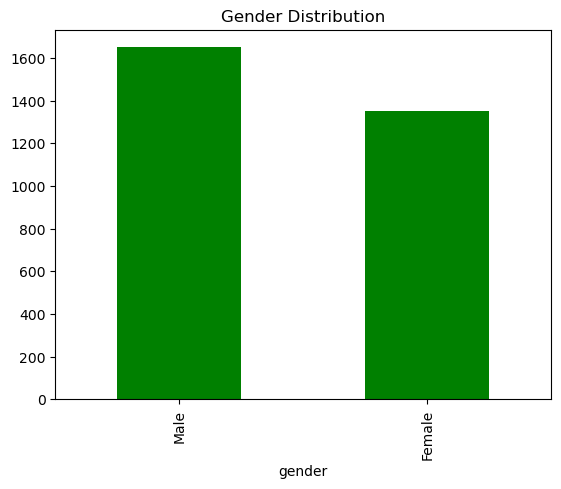

In [31]:
#plot of the gender distribution of newborns
newborn_health['gender'].value_counts().plot(kind='bar',title= "Gender Distribution",color='g')

From the above, we can tell that the number of males born is higher than the female newborns.This generally provides the baseline population structure.
Male infants often have slightly higher average birth weights.

In [32]:
#Average birth weight, lenght and head_circumference
df=newborn_health
birth_stats = df[['birth_weight_kg','birth_length_cm', 'birth_head_circumference_cm']].describe()
birth_stats

,birth_weight_kg,birth_length_cm,birth_head_circumference_cm
count,3000.000000,3000.000000,3000.000000
mean,3.205000,49.727000,34.128000
std,0.561555,2.145065,1.486254
min,1.860000,45.100000,31.200000
25%,2.870000,48.475000,32.975000
50%,3.165000,49.550000,34.100000
75%,3.625000,51.025000,34.800000
max,4.470000,55.800000,38.100000


We can tell that the average birth weight of infants is 3.2 kg with their average birth length being 49.7cm and head circumference of 34.1cm irregardless of gender.

<Axes: title={'center': 'Average Growth Over Age (Days)'}, xlabel='age_days'>

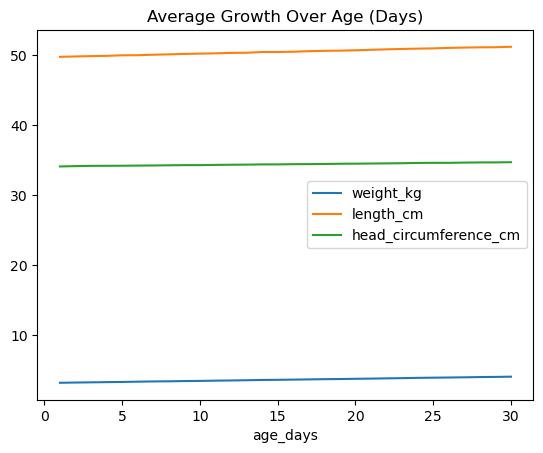

In [33]:
# Growth trend over first days
avg_growth = df.groupby('age_days')[['weight_kg','length_cm','head_circumference_cm']].mean()
avg_growth.plot(title="Average Growth Over Age (Days)")

There's a steady increases in weight, lenght and head_circumference. Any plateau or drop in these factors is clinically concerning. Gender differences in growth should align with known paediatric norms.

Text(0.5, 1.0, 'Weight Growth by Gender')

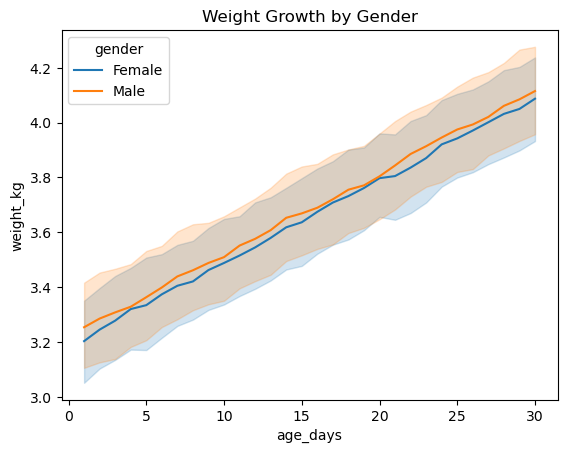

In [34]:
#Growth patterns between the Gender (weight)
sns.lineplot(x='age_days',y='weight_kg', hue='gender', data=df)
plt.title("Weight Growth by Gender")

There steady weight growth between the two genders which is to be expected from healthy infants. However, male infants seem to gain more weight by age days as compared to female infants

Text(0.5, 1.0, 'Weight Gain by Feeding Type')

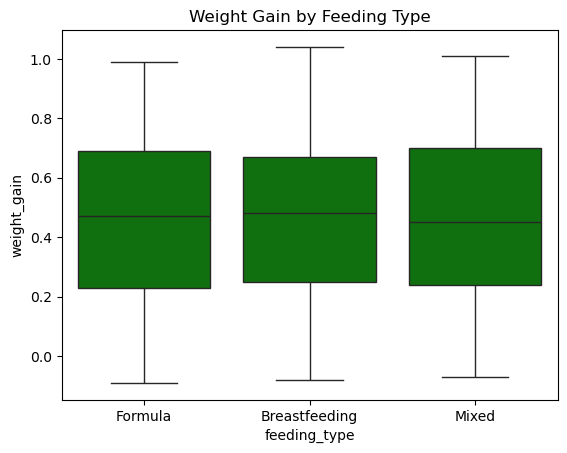

In [36]:
#Feeding patterns impact on weight gain
sns.boxplot(x='feeding_type', y='weight_gain', data=df, color='g')
plt.title("Weight Gain by Feeding Type")

Breatfeeding infants seem to have gained slightly more weight as compared to Formula feeding infants.With the infants feeding from both Formula and breastfeeding having gained least weight, we can safely conclude that its not the best approach to promote weight gain in infants.

array([[<Axes: title={'center': 'temperature_c'}>,
        <Axes: title={'center': 'heart_rate_bpm'}>],
       [<Axes: title={'center': 'respiratory_rate_bpm'}>,
        <Axes: title={'center': 'oxygen_saturation'}>]], dtype=object)

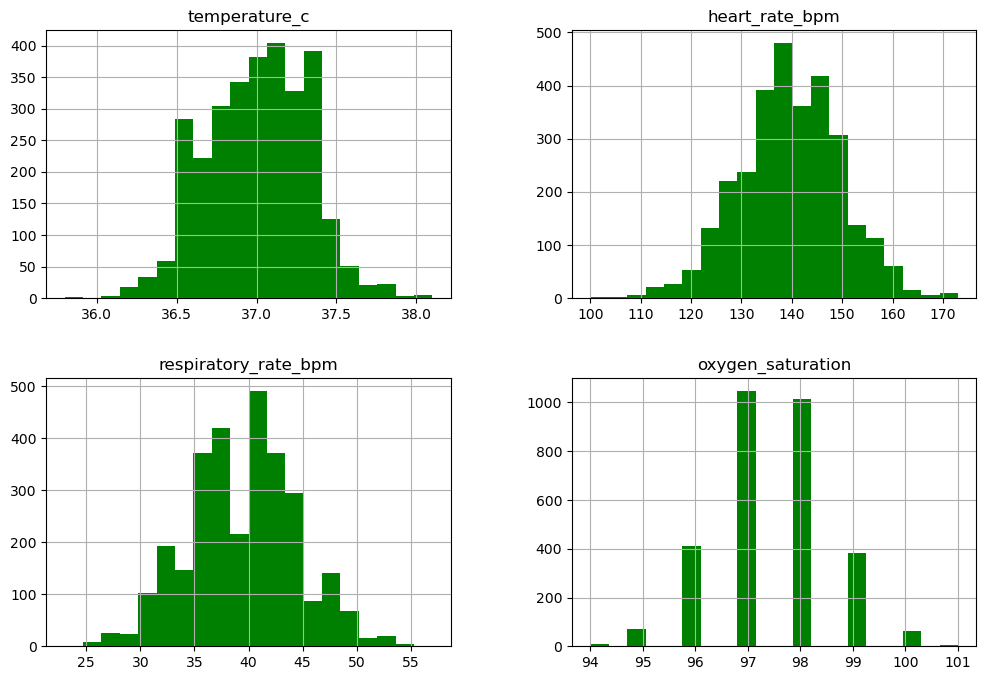

In [39]:
# Distribution of vital signs
vitals = ['temperature_c','heart_rate_bpm','respiratory_rate_bpm','oxygen_saturation']
df[vitals].hist(bins=20, figsize=(12,8), color='g')

Text(0.5, 1.0, 'Temperature by Risk Level')

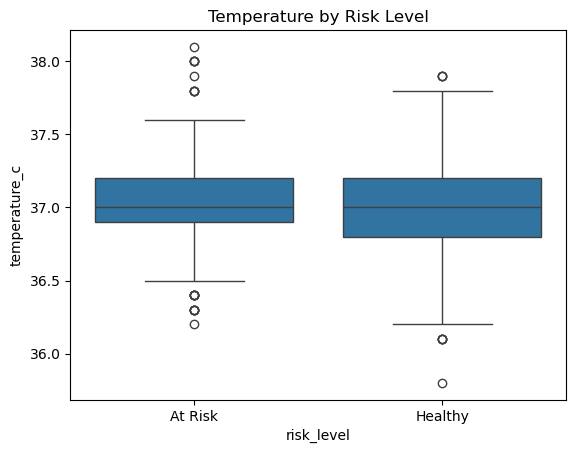

In [40]:
# Compare vitals between Healthy vs At Risk
sns.boxplot(x='risk_level', y='temperature_c', data=df)
plt.title("Temperature by Risk Level")

Text(0.5, 1.0, 'Oxygen Saturation by Risk Level')

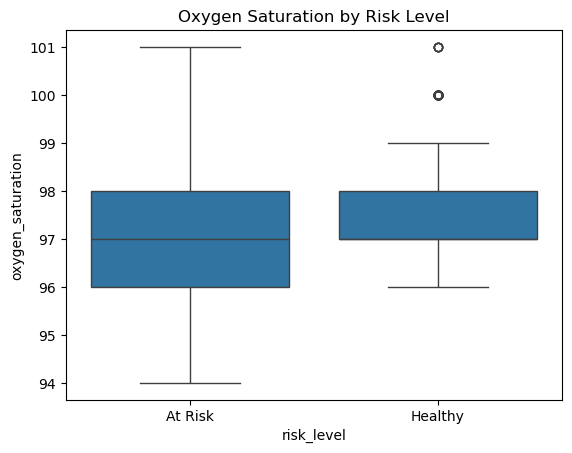

In [41]:
sns.boxplot(x='risk_level', y='oxygen_saturation', data=df)
plt.title("Oxygen Saturation by Risk Level")


Comparing Healthy vs At Risk groups reveals that sick infants have lower oxygen saturation andmore temperature instability.
Distributions show vitals cluster around normal neonatal ranges (Temp: 36.5–37.5°C


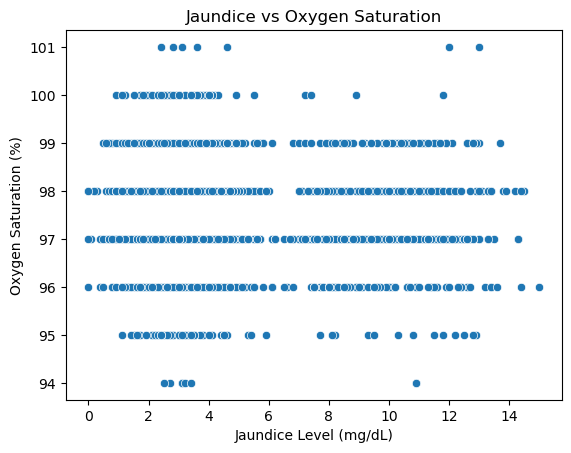

In [43]:
#correlation between high jaundice levels and lower oxygen saturation
sns.scatterplot(x='jaundice_level_mg_dl', y='oxygen_saturation', data=df)
plt.title("Jaundice vs Oxygen Saturation")
plt.xlabel("Jaundice Level (mg/dL)")
plt.ylabel("Oxygen Saturation (%)")
plt.show()

In [44]:
corr = df['jaundice_level_mg_dl'].corr(df['oxygen_saturation'])
print(f"Correlation coefficient: {corr:.2f}")


Correlation coefficient: -0.01


From the scatterplot you can tell there's almost no linear relashinship betwen the jaundice level and oxgen saturation. The correlation being -0.01 confirms there’s no meaningful relationship between jaundice levels and oxygen saturation in this study.

<Axes: xlabel='age_days', ylabel='feeding_frequency_per_day'>

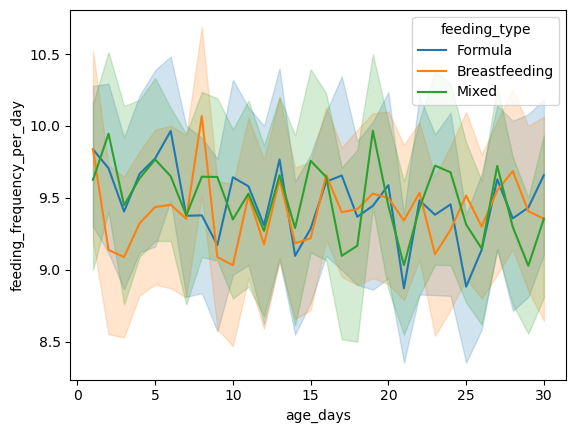

In [45]:
#feeding frequency with age and feeding type
sns.lineplot(x='age_days', y='feeding_frequency_per_day', hue='feeding_type', data=df)


In [ ]:
Feeding type distribution shows reliance on breastfeeding vs. formula.
Feeding frequency trends by age days decline gradually as infants feed less often but likely in larger volumes.
NOTE: Adequate feeding and hydration are cornerstones of newborn health. Early feeding problems may correlate with weight loss and jaundice.


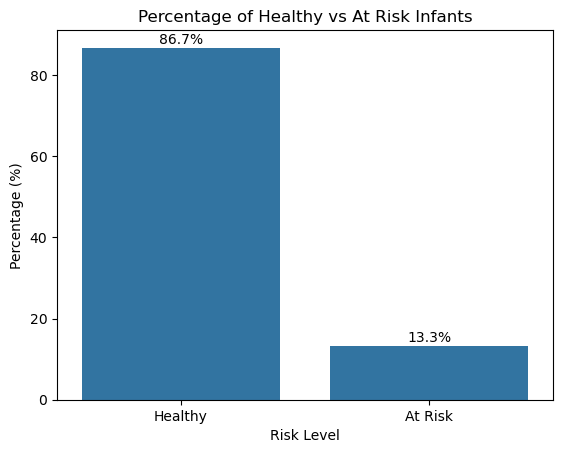

In [49]:
#percentage of babies are categorized as “Healthy” vs. “At Risk"
counts = df['risk_level'].value_counts(normalize=True) * 100

sns.barplot(x=counts.index, y=counts.values)
plt.title("Percentage of Healthy vs At Risk Infants")
plt.xlabel("Risk Level")
plt.ylabel("Percentage (%)")

for i, v in enumerate(counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

 Shows overall prevalence of risk classification in the monitored population. If a large proportion are “At Risk,” that may reflect high incidence of low birth weight, jaundice, or feeding issues.
NOTE This provides a high-level view of how many infants require closer follow-up or interventions.


Text(0.5, 1.0, 'Relationship between Different Features')

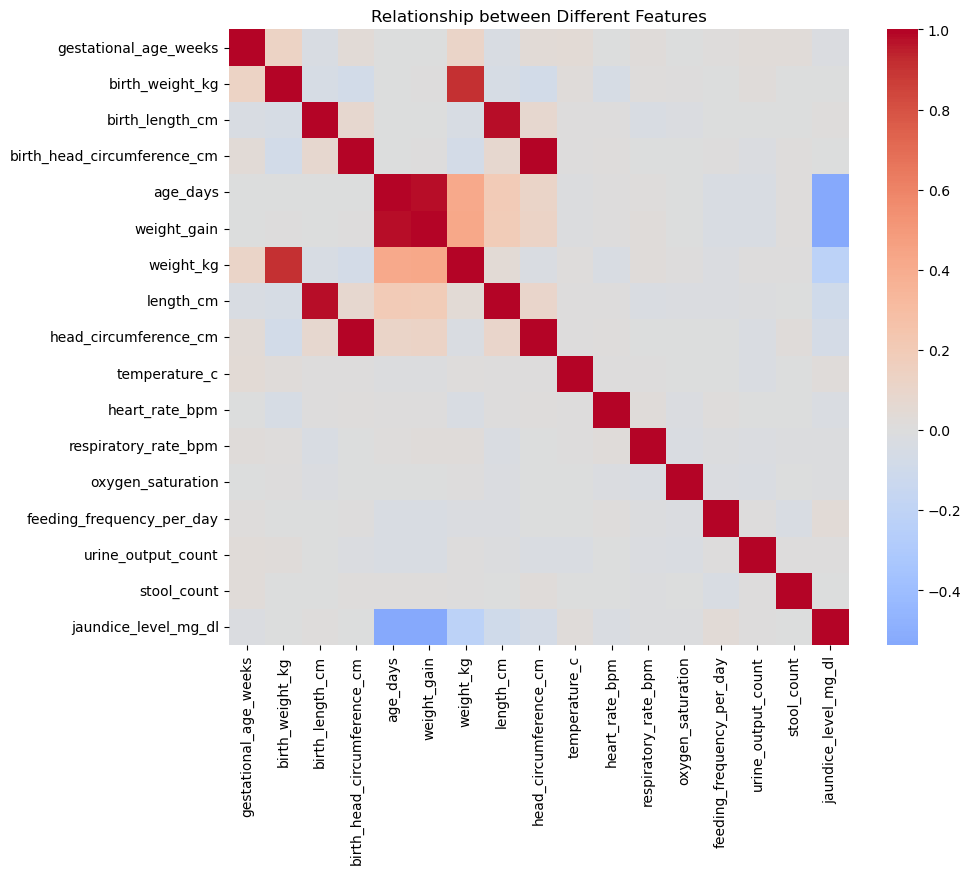

In [50]:
#features that are most strongly associated with being At Risk
risk_corr= df.drop(columns=['baby_id','name','date','gender','feeding_type','immunizations_done','reflexes_normal','risk_level', 'apgar_score']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(risk_corr, cmap="coolwarm", center=0)
plt.title("Relationship between Different Features")

•	Identifies which variables move together for example birth weight correlates with gestational age(corr=+1), at the same time jaundice level show no relationship with oxygen saturation(negative correlation).
•	NOTE: Useful for discovering which indicators are most predictive of neonatal risk and guiding screening priorities.


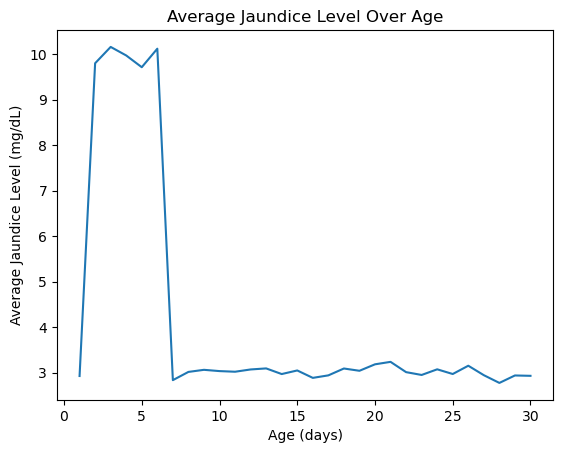

In [51]:
# Jaundice level trend with age
age_trend = df.groupby('age_days')['jaundice_level_mg_dl'].mean().reset_index()

sns.lineplot(x='age_days', y='jaundice_level_mg_dl', data=age_trend)
plt.title("Average Jaundice Level Over Age")
plt.xlabel("Age (days)")
plt.ylabel("Average Jaundice Level (mg/dL)")
plt.show()


Rises in the first few days
Peaks around day 3–5
Falls gradually as the baby’s liver matures in a few days signaling a normal physiological pattern.
NOTE : Early jaundice screening is crucial to prevent complications.

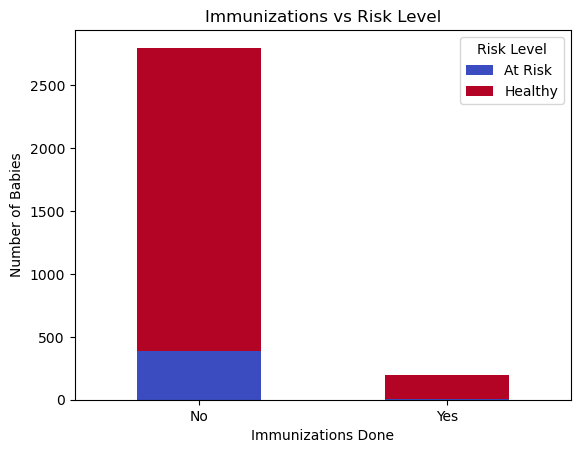

In [52]:
#Immunization vs Risk
ct = pd.crosstab(df['immunizations_done'], df['risk_level'])
ct.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title("Immunizations vs Risk Level")
plt.xlabel("Immunizations Done")
plt.ylabel("Number of Babies")
plt.legend(title="Risk Level")
plt.xticks(rotation=0)
plt.show()


Infants with completed immunizations  fall into the 'Healthy' group. Those without immunizations may be overrepresented in the 'At Risk' group.
This plot Reinforces the protective role of early immunization in reducing risk
From the plot, its clear that only a small portion of infants that have not been immunized are at risk.

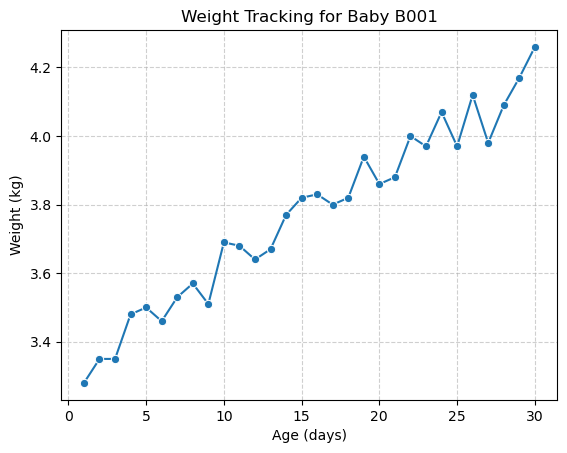

In [54]:
#track weight over time for first baby
baby_id = df['baby_id'].iloc[0]
baby_data = df[df['baby_id'] == baby_id].sort_values(by='age_days')
sns.lineplot(x='age_days', y='weight_kg', data=baby_data, marker="o")
plt.title(f"Weight Tracking for Baby {baby_id}")
plt.xlabel("Age (days)")
plt.ylabel("Weight (kg)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


From the plot its clear that Baby B001 is a healthy baby as it gains weight steadily after the first few days (after initial physiological weight loss) which is expected. 
Drops or flat trends may indicate feeding problems or illness.
